# Template Eksperimen MSML
## 1. Perkenalan Dataset
Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

**Sumber Dataset:**
Dataset yang digunakan adalah **Titanic - Machine Learning from Disaster** yang diperoleh dari Kaggle. Dataset ini berisi informasi penumpang kapal Titanic, termasuk apakah mereka selamat atau tidak.

**Tujuan:**
Membangun model untuk memprediksi keselamatan penumpang berdasarkan berbagai fitur seperti umur, jenis kelamin, kelas tiket, dll.

## 2. Import Library
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 3. Memuat Dataset
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset dari folder dataset_raw
df = pd.read_csv('../dataset_raw/titanic_train.csv')

# Menampilkan 5 baris pertama dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Exploratory Data Analysis (EDA)
Pada tahap ini, Anda akan melakukan Exploratory Data Analysis (EDA) untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Statistik Deskriptif:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Jumlah Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/var/folders/r7/b6plm61x653475vpv5073zc40000gn/T/ipykernel_83023/886614484.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


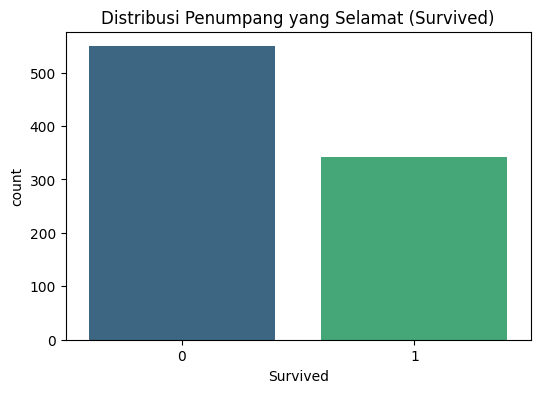

In [3]:
# Memeriksa informasi umum dataset
print("Informasi Dataset:")
df.info()

# Memeriksa statistik deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

# Memeriksa missing values
print("\nJumlah Missing Values:")
print(df.isnull().sum())

# Visualisasi distribusi target (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Distribusi Penumpang yang Selamat (Survived)')
plt.show()

## 5. Data Preprocessing
Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang dilakukan:
1. Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Encoding Data Kategorikal
4. Feature Selection (Menghapus kolom yang tidak relevan)

In [4]:
# 1. Menangani Data Kosong
# Mengisi Age yang kosong dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Mengisi Embarked yang kosong dengan modus
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Menghapus kolom Cabin karena terlalu banyak missing values
df.drop(columns=['Cabin'], inplace=True)

# 2. Menghapus Data Duplikat
df.drop_duplicates(inplace=True)

# 3. Feature Selection
# Menghapus kolom yang tidak memberikan informasi prediktif yang kuat untuk model dasar
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

# 4. Encoding Data Kategorikal
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print("Hasil Preprocessing:")
df.head()

Hasil Preprocessing:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
